# Consumer Review Analysis: Voice of the Customer

## Research Question

**What product attributes and consumer experience factors are associated with customer satisfaction in the smart TV market, and how do major brands differ in their competitive positioning?**

The exploratory analysis showed that basic product specifications such as
screen size and resolution provide limited differentiation in customer
ratings. This notebook therefore shifts from product specifications to the
consumer experience expressed in review text.

The analysis uses customer reviews to identify recurring aspects of the
Smart TV ownership experience, measure how frequently consumers discuss
those aspects, examine their relationship with satisfaction, and compare
Samsung with LG, Sony, TCL, and Hisense.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [49]:
import os

FIGURE_DIR = "outputs/figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

In [66]:
products = pd.read_parquet(
    "tv_products_analysis.parquet"
)

reviews = pd.read_parquet(
    "tv_reviews_analysis.parquet"
)

print("Products:", products.shape)
print("Reviews:", reviews.shape)

print("\nReview columns:")
print(reviews.columns.tolist())

Products: (1097, 20)
Reviews: (111191, 14)

Review columns:
['rating', 'title', 'text', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'brand', 'review_date', 'review_year', 'text_clean', 'text_length']


In [51]:
display(
    reviews[
        [
            "brand",
            "rating",
            "title",
            "text_clean"
        ]
    ].sample(
        10,
        random_state=42
    )
)

,brand,rating,title,text_clean
69135,TCL,5.0,Five Stars,This tv has a great picture for the price. Get the antennae for local channels
23910,Samsung,3.0,Meh,Don't care for the Samsung built-in software. Wish it could default to my options.
89946,TCL,2.0,Won’t stay connected to the internet,Bought in August. Product won’t stay connected to the internet.
28159,TCL,4.0,Good picture,Don’t like Remote Control.
80417,TCL,5.0,First ever TV purchase and im very satisfied!,Wow! Amazing picture quality and holy cow this is just perfect for gaming! It sounds divine and the cute little roku remote is the bees knees! My only regret...<br />I opted out for the sound bar ...
39200,TCL,5.0,Great and affordable TV,Big fan of Roku and having it integrated into the TV makes it even better. Picture and sound quality are great.
4704,Hisense,5.0,Great picture and amazing sound!,"This is my first Android TV experience and my first introduction to the Hisense brand. Very happy with the picture, very vibrant and you can definitely notice the higher contrast and deep black wi..."
4343,LG,5.0,Great TV,"Great picture , remote has a pointer feature that I like"
56062,Hisense,2.0,Worked great for 6 months.,It was fine for the 6 months that it worked. I use this as a 2nd monitor for streaming and it just puked out on me today. The screen became very dark when trying to use any of the HDMI ports. I kn...
100868,TCL,1.0,"One year, 7 days - dead pixels",Very disappointing to find dead pixels that quickly. It's been treated well.


In [52]:
reviews["word_count"] = (
    reviews["text_clean"]
    .fillna("")
    .str.split()
    .str.len()
)

display(
    reviews["word_count"]
    .describe()
)

,word_count
count,111191.000000
mean,64.009866
std,111.514700
min,1.000000
25%,11.000000
50%,30.000000
75%,73.000000
max,3494.000000


In [53]:
from sklearn.feature_extraction.text import CountVectorizer

In [54]:
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=50,
    max_df=0.90,
    max_features=5000
)

X = vectorizer.fit_transform(
    reviews["text_clean"].fillna("")
)

print("Document-term matrix:")
print(X.shape)

Document-term matrix:
(111191, 5000)


In [55]:
term_counts = np.asarray(
    X.sum(axis=0)
).ravel()

terms = vectorizer.get_feature_names_out()

top_terms = (
    pd.DataFrame({
        "term": terms,
        "count": term_counts
    })
    .sort_values(
        "count",
        ascending=False
    )
)

display(
    top_terms.head(50)
)

,term,count
4292,tv,170105
591,br,100593
2934,picture,50840
1831,great,45067
604,br br,35795
3230,quality,28530
1781,good,26950
3401,remote,25714
3899,sound,24893
2182,just,23426


In [56]:
top_bigrams = (
    top_terms[
        top_terms["term"]
        .str.contains(" ")
    ]
    .head(50)
)

display(
    top_bigrams
)

,term,count
604,br br,35795
2974,picture quality,13810
1869,great tv,7024
3848,smart tv,6393
1855,great picture,6358
3902,sound bar,4163
4389,tv great,4133
1405,easy set,4073
2472,love tv,4042
4321,tv br,3126


In [57]:
positive_reviews = reviews[
    reviews["rating"] >= 4
]

negative_reviews = reviews[
    reviews["rating"] <= 2
]

print(
    "Positive reviews:",
    len(positive_reviews)
)

print(
    "Negative reviews:",
    len(negative_reviews)
)

Positive reviews: 77875
Negative reviews: 25962


In [58]:
def get_top_bigrams(text_series, top_n=30):

    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=(2, 2),
        min_df=20,
        max_features=3000
    )

    X = vectorizer.fit_transform(
        text_series.fillna("")
    )

    counts = np.asarray(
        X.sum(axis=0)
    ).ravel()

    terms = (
        vectorizer
        .get_feature_names_out()
    )

    result = pd.DataFrame({
        "bigram": terms,
        "count": counts
    })

    return (
        result
        .sort_values(
            "count",
            ascending=False
        )
        .head(top_n)
    )

In [59]:
positive_bigrams = get_top_bigrams(
    positive_reviews["text_clean"]
)

negative_bigrams = get_top_bigrams(
    negative_reviews["text_clean"]
)

print("TOP BIGRAMS — POSITIVE REVIEWS")
display(positive_bigrams)

print("\nTOP BIGRAMS — NEGATIVE REVIEWS")
display(negative_bigrams)

TOP BIGRAMS — POSITIVE REVIEWS


,bigram,count
354,br br,21635
1729,picture quality,10720
1099,great tv,6334
1076,great picture,5675
2236,smart tv,4569
807,easy set,3872
1457,love tv,3803
2543,tv great,3297
2260,sound bar,3285
812,easy use,2698



TOP BIGRAMS — NEGATIVE REVIEWS


,bigram,count
287,br br,10010
598,customer service,2000
1483,picture quality,1905
1977,smart tv,1251
263,bought tv,1152
2071,stopped working,1139
1379,new tv,1027
1833,samsung tv,902
456,buy tv,896
2309,tv br,879


In [60]:
def clean_review_for_analysis(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    # Remove HTML break artifacts
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'\bbr\b', ' ', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


reviews["text_analysis"] = (
    reviews["text_clean"]
    .apply(clean_review_for_analysis)
)

display(
    reviews[
        ["text_clean", "text_analysis"]
    ].sample(
        5,
        random_state=42
    )
)

,text_clean,text_analysis
69135,This tv has a great picture for the price. Get the antennae for local channels,this tv has a great picture for the price. get the antennae for local channels
23910,Don't care for the Samsung built-in software. Wish it could default to my options.,don't care for the samsung built-in software. wish it could default to my options.
89946,Bought in August. Product won’t stay connected to the internet.,bought in august. product won’t stay connected to the internet.
28159,Don’t like Remote Control.,don’t like remote control.
80417,Wow! Amazing picture quality and holy cow this is just perfect for gaming! It sounds divine and the cute little roku remote is the bees knees! My only regret...<br />I opted out for the sound bar ...,wow! amazing picture quality and holy cow this is just perfect for gaming! it sounds divine and the cute little roku remote is the bees knees! my only regret... i opted out for the sound bar and s...


In [61]:
print(
    "Reviews containing standalone 'br':",
    reviews["text_analysis"]
    .str.contains(
        r'\bbr\b',
        regex=True,
        na=False
    )
    .sum()
)

Reviews containing standalone 'br': 0


In [62]:
aspect_patterns = {
    "Picture Quality": [
        r"\bpicture\b",
        r"\bimage quality\b",
        r"\bdisplay quality\b",
        r"\bcolor(?:s)?\b",
        r"\bbrightness\b",
        r"\bcontrast\b",
        r"\bhdr\b",
        r"\bblack level(?:s)?\b",
        r"\bblack screen\b"
    ],

    "Sound": [
        r"\bsound quality\b",
        r"\baudio\b",
        r"\bspeaker(?:s)?\b",
        r"\bvolume\b",
        r"\bsound\b"
    ],

    "Ease of Use & Setup": [
        r"\beasy to use\b",
        r"\beasy use\b",
        r"\beasy to set up\b",
        r"\beasy setup\b",
        r"\beasy set\b",
        r"\bsetup\b",
        r"\bset up\b",
        r"\binstallation\b"
    ],

    "Smart Features & Apps": [
        r"\bsmart feature(?:s)?\b",
        r"\bapp(?:s)?\b",
        r"\bstreaming\b",
        r"\bnetflix\b",
        r"\bhulu\b",
        r"\byoutube\b",
        r"\bamazon prime\b",
        r"\broku\b",
        r"\bwebos\b",
        r"\bandroid tv\b",
        r"\bgoogle tv\b"
    ],

    "Remote": [
        r"\bremote\b",
        r"\bremote control\b"
    ],

    "Reliability": [
        r"\bstopped working\b",
        r"\bstop(?:ped)? working\b",
        r"\bdoesn'?t work\b",
        r"\bdoes not work\b",
        r"\bwon'?t work\b",
        r"\bwill not work\b",
        r"\bnot working\b",
        r"\bwon'?t turn on\b",
        r"\bwill not turn on\b",
        r"\bblack screen\b",
        r"\bdead pixels?\b",
        r"\bdefective\b",
        r"\bmalfunction(?:ed|ing)?\b",
        r"\bscreen (?:went|goes|went) (?:black|out)\b",
        r"\bsound (?:went|goes) out\b",
        r"\bfailed\b",
        r"\bfailure\b"
    ],


    "Customer Support": [
        r"\bcustomer service\b",
        r"\bcustomer support\b",
        r"\btech support\b",
        r"\btechnical support\b",
        r"\bwarranty\b",
        r"\brepair\b"
    ],

    "Value": [
        r"\bprice\b",
        r"\bvalue\b",
        r"\bworth\b",
        r"\bmoney\b",
        r"\bexpensive\b",
        r"\bcheap\b",
        r"\baffordable\b"
    ]
}

In [63]:
reliability_patterns = [
    r"\bstopped working\b",
    r"\bstop(?:ped)? working\b",
    r"\bdoesn'?t work\b",
    r"\bdoes not work\b",
    r"\bwon'?t work\b",
    r"\bwill not work\b",
    r"\bnot working\b",
    r"\bwon'?t turn on\b",
    r"\bwill not turn on\b",
    r"\bblack screen\b",
    r"\bdead pixels?\b",
    r"\bdefective\b",
    r"\bmalfunction(?:ed|ing)?\b",
    r"\bscreen (?:went|goes|went) (?:black|out)\b",
    r"\bsound (?:went|goes) out\b",
    r"\bfailed\b",
    r"\bfailure\b"
]

reliability_regex = "|".join(
    f"(?:{pattern})"
    for pattern in reliability_patterns
)

reviews["Reliability"] = (
    reviews["text_analysis"]
    .str.contains(
        reliability_regex,
        case=False,
        regex=True,
        na=False
    )
)

print(
    "Reliability mentions:",
    reviews["Reliability"].sum()
)

print(
    "Reliability mention rate:",
    round(
        reviews["Reliability"].mean() * 100,
        2
    ),
    "%"
)

display(
    reviews.loc[
        reviews["Reliability"],
        ["brand", "rating", "text_analysis"]
    ].sample(
        10,
        random_state=42
    )
)

Reliability mentions: 6824
Reliability mention rate: 6.14 %


,brand,rating,text_analysis
1972,Hisense,1.0,"worked perfectly, then dark lines or banding issue developed in all of the picture within 20 days. darkish horizontal lines that do not move or change throughout the entire picture, including oper..."
49451,LG,5.0,"thing's i liked: picture quality was very good, color was excellent as you'd expect from ips panel, up to date connections hdmi 2.1, 120hz refresh rate (that's the actual refresh rate not what you..."
69207,TCL,5.0,remote needs improving. slow to respond. does not work on first push
44470,Sony,3.0,this tv lasted 3 and a half months whet black now i have a red flashing light on the bottom and i have had to deal with sony wanting to repair my 3 1/2 month old tv that i am still paying for. do ...
94213,Hisense,3.0,"the picture and sound quality are above and beyond for the price. the only reason i didnt give it 5 stars is because there are a couple of problems, the remote connection is very delayed which isn..."
28382,Samsung,3.0,"even though i purchased this in august 2019, i didn't unbox it and set it up until about 6 weeks ago. i bought it for my guest room, but couldn't find anyone to help me with installation so it sat..."
42967,Samsung,4.0,only 4 stars now to see if it last over a year. the last one i bought stopped working 2 months out of warranty. samsung refused to provided any assistance whatsoever.
105343,Hisense,1.0,"just don't buy it guys. i know the features it provides look good. but there is a issue on these tvs. i ordered one. that did not work. and i gave another chance and asked for replacement, but the..."
97645,TCL,1.0,after 7 months of using the tcl 65r625 i have found three things to be annoying. 1) the tv audio does not work well with the roku app on my motorola android cell phone. at times the audio breaks u...
92891,Hisense,2.0,"good picture quality and brightness, but screen displayed a defective flashing patterns every couple of hours which took the whole screen up and interrupted my viewing so had to return."


In [67]:
aspect_summary = []

for aspect in aspect_patterns.keys():

    subset = reviews[
        reviews[aspect]
    ]

    aspect_summary.append({
        "aspect": aspect,
        "mentions": len(subset),
        "mention_rate": (
            len(subset) / len(reviews) * 100
        ),
        "avg_rating": subset["rating"].mean(),
        "positive_rate": (
            (subset["rating"] >= 4).mean() * 100
        ),
        "negative_rate": (
            (subset["rating"] <= 2).mean() * 100
        )
    })

aspect_summary = (
    pd.DataFrame(aspect_summary)
    .sort_values(
        "mention_rate",
        ascending=False
    )
)

display(
    aspect_summary.round(2)
)

KeyError: 'Picture Quality'

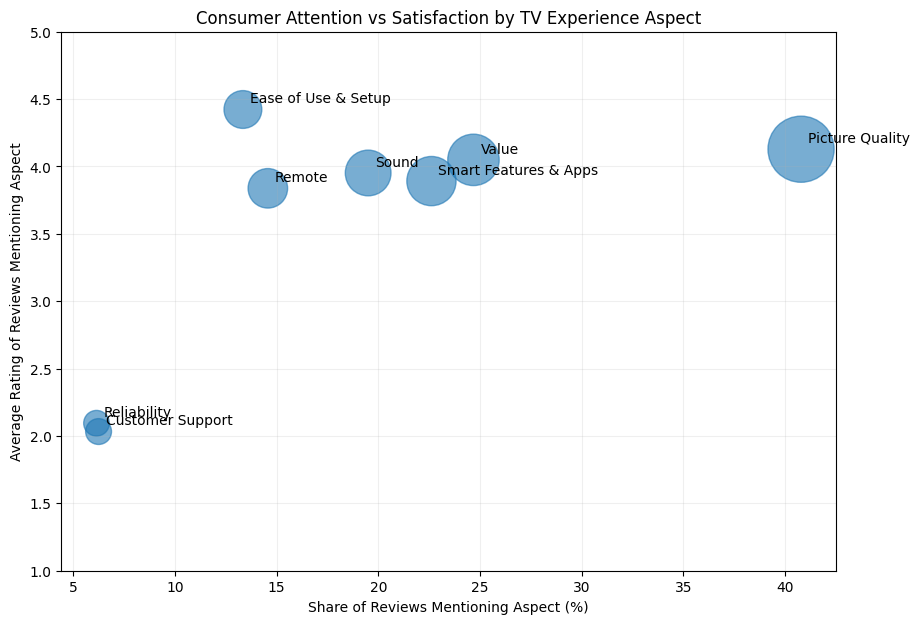

In [36]:
plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    aspect_summary["mention_rate"],
    aspect_summary["avg_rating"],
    s=aspect_summary["mentions"] / 20,
    alpha=0.6
)

for _, row in aspect_summary.iterrows():

    plt.annotate(
        row["aspect"],
        (
            row["mention_rate"],
            row["avg_rating"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel(
    "Share of Reviews Mentioning Aspect (%)"
)

plt.ylabel(
    "Average Rating of Reviews Mentioning Aspect"
)

plt.title(
    "Consumer Attention vs Satisfaction by TV Experience Aspect"
)

plt.ylim(1, 5)

plt.grid(
    alpha=0.2
)

# Consumer Attention vs Satisfaction
plt.savefig(
    f"{FIGURE_DIR}/04_attention_vs_satisfaction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
brand_aspect_rows = []

for brand in reviews["brand"].unique():

    brand_reviews = reviews[
        reviews["brand"] == brand
    ]

    for aspect in aspect_patterns.keys():

        subset = brand_reviews[
            brand_reviews[aspect]
        ]

        brand_aspect_rows.append({
            "brand": brand,
            "aspect": aspect,
            "mentions": len(subset),
            "mention_rate": (
                len(subset)
                / len(brand_reviews)
                * 100
            ),
            "avg_rating": (
                subset["rating"].mean()
                if len(subset) > 0
                else np.nan
            ),
            "positive_rate": (
                (subset["rating"] >= 4).mean() * 100
                if len(subset) > 0
                else np.nan
            ),
            "negative_rate": (
                (subset["rating"] <= 2).mean() * 100
                if len(subset) > 0
                else np.nan
            )
        })

brand_aspect = pd.DataFrame(
    brand_aspect_rows
)

display(
    brand_aspect.head(10)
)

,brand,aspect,mentions,mention_rate,avg_rating,positive_rate,negative_rate
0,TCL,Picture Quality,14207,34.185134,4.090308,75.688041,16.794538
1,TCL,Sound,7336,17.652013,3.887132,70.474373,20.747001
2,TCL,Ease of Use & Setup,6019,14.483024,4.467353,87.489616,8.390098
3,TCL,Smart Features & Apps,11972,28.807238,3.955981,71.959572,19.963248
4,TCL,Remote,6164,14.831926,3.833550,69.078520,20.717067
5,TCL,Reliability,2664,6.410164,2.032658,19.369369,70.307808
6,TCL,Customer Support,2444,5.880796,2.003273,19.476268,72.585925
7,TCL,Value,12520,30.125845,4.136422,78.162939,16.078275
8,Samsung,Picture Quality,13773,42.168269,4.112466,75.648007,16.554128
9,Samsung,Sound,5955,18.232196,3.926280,70.680101,19.546599


In [26]:
rating_matrix = (
    brand_aspect
    .pivot(
        index="aspect",
        columns="brand",
        values="avg_rating"
    )
)

rating_matrix = rating_matrix[
    [
        "Samsung",
        "LG",
        "Sony",
        "TCL",
        "Hisense"
    ]
]

display(
    rating_matrix.round(2)
)

brand,Samsung,LG,Sony,TCL,Hisense
aspect,,,,,
Customer Support,1.91,2.22,2.11,2.00,2.17
Ease of Use & Setup,4.40,4.45,4.41,4.47,4.26
Picture Quality,4.11,4.25,4.20,4.09,4.00
Reliability,2.07,2.35,2.32,2.03,1.89
Remote,3.84,3.98,3.97,3.83,3.40
Smart Features & Apps,3.86,3.90,3.89,3.96,3.61
Sound,3.93,4.13,4.06,3.89,3.84
Value,3.88,4.16,4.00,4.14,3.95


In [27]:
mention_matrix = (
    brand_aspect
    .pivot(
        index="aspect",
        columns="brand",
        values="mention_rate"
    )
)

mention_matrix = mention_matrix[
    [
        "Samsung",
        "LG",
        "Sony",
        "TCL",
        "Hisense"
    ]
]

display(
    mention_matrix.round(2)
)

brand,Samsung,LG,Sony,TCL,Hisense
aspect,,,,,
Customer Support,6.19,5.32,7.02,5.88,8.40
Ease of Use & Setup,12.97,11.38,14.07,14.48,11.80
Picture Quality,42.17,46.40,52.13,34.19,41.51
Reliability,6.03,4.44,6.67,6.41,7.31
Remote,16.07,12.54,14.18,14.83,12.01
Smart Features & Apps,16.80,17.28,23.20,28.81,23.23
Sound,18.23,21.54,23.90,17.65,22.99
Value,18.83,21.09,21.92,30.13,30.16


In [1]:
import os

os.makedirs("outputs/tables", exist_ok=True)

rating_matrix.to_csv(
    "outputs/tables/brand_aspect_ratings.csv"
)

mention_matrix.to_csv(
    "outputs/tables/brand_aspect_mentions.csv"
)

print("Saved brand-aspect tables.")

NameError: name 'rating_matrix' is not defined

In [69]:
rating_matrix.to_csv("brand_aspect_ratings.csv")
mention_matrix.to_csv("brand_aspect_mentions.csv")

print("Saved brand-aspect tables.")

Saved brand-aspect tables.


Rating matrix:

When consumers discuss this aspect, how satisfied are they?

Mention matrix:

How prominent is this aspect in each brand's consumer conversation?

In [28]:
competitors = [
    "LG",
    "Sony",
    "TCL",
    "Hisense"
]

samsung_position = pd.DataFrame({
    "Samsung": rating_matrix["Samsung"],
    "Competitor Avg": (
        rating_matrix[competitors]
        .mean(axis=1)
    )
})

samsung_position["Gap"] = (
    samsung_position["Samsung"]
    - samsung_position["Competitor Avg"]
)

samsung_position["Samsung Mention Rate"] = (
    mention_matrix["Samsung"]
)

samsung_position = (
    samsung_position
    .sort_values(
        "Gap",
        ascending=False
    )
)

display(
    samsung_position.round(2)
)

,Samsung,Competitor Avg,Gap,Samsung Mention Rate
aspect,,,,
Remote,3.84,3.80,0.05,16.07
Smart Features & Apps,3.86,3.84,0.02,16.80
Ease of Use & Setup,4.40,4.40,-0.00,12.97
Picture Quality,4.11,4.13,-0.02,42.17
Sound,3.93,3.98,-0.05,18.23
Reliability,2.07,2.15,-0.08,6.03
Value,3.88,4.06,-0.18,18.83
Customer Support,1.91,2.13,-0.22,6.19


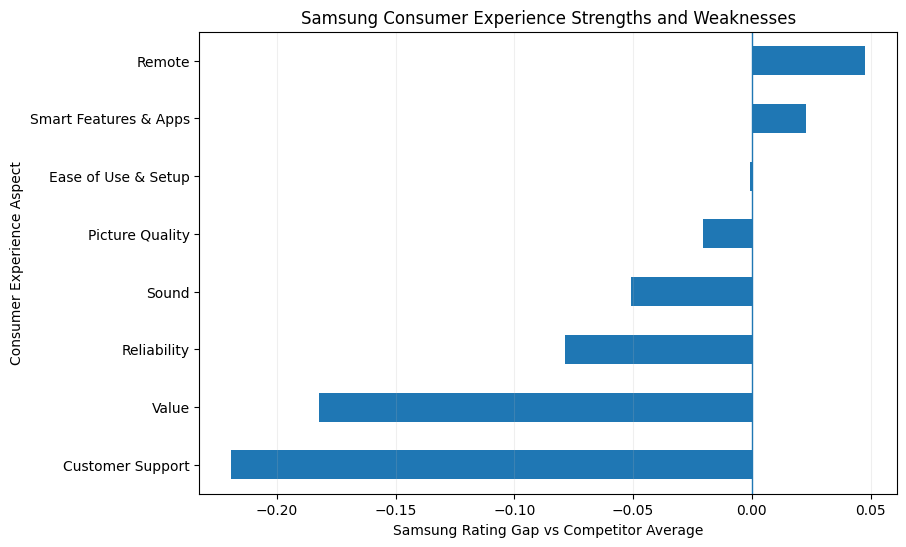

In [37]:
plot_data = (
    samsung_position["Gap"]
    .sort_values()
)

plt.figure(
    figsize=(9, 6)
)

plot_data.plot(
    kind="barh"
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel(
    "Samsung Rating Gap vs Competitor Average"
)

plt.ylabel(
    "Consumer Experience Aspect"
)

plt.title(
    "Samsung Consumer Experience Strengths and Weaknesses"
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.savefig(
    f"{FIGURE_DIR}/04_samsungconsumerexperienceon.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
import statsmodels.api as sm

aspect_columns = list(
    aspect_patterns.keys()
)

X = reviews[
    aspect_columns
].astype(int).copy()

X = sm.add_constant(X)

y = reviews["rating"]

ols_model = sm.OLS(
    y,
    X
).fit(
    cov_type="HC3"
)

print(
    ols_model.summary()
)

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     3659.
Date:                Tue, 15 Sep 2026   Prob (F-statistic):               0.00
Time:                        06:08:51   Log-Likelihood:            -1.9642e+05
No. Observations:              111191   AIC:                         3.929e+05
Df Residuals:                  111182   BIC:                         3.930e+05
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     3.84

In [31]:
driver_results = pd.DataFrame({
    "coefficient": ols_model.params,
    "std_error": ols_model.bse,
    "p_value": ols_model.pvalues
})

driver_results = (
    driver_results
    .drop(
        index="const"
    )
    .sort_values(
        "coefficient",
        ascending=False
    )
)

display(
    driver_results.round(4)
)

,coefficient,std_error,p_value
Ease of Use & Setup,0.5224,0.0102,0.0000
Picture Quality,0.3665,0.0090,0.0000
Value,0.1998,0.0094,0.0000
Sound,-0.0352,0.0106,0.0009
Smart Features & Apps,-0.0762,0.0104,0.0000
Remote,-0.1077,0.0121,0.0000
Reliability,-1.5137,0.0184,0.0000
Customer Support,-1.6194,0.0188,0.0000


In [32]:
brand_dummies = pd.get_dummies(
    reviews["brand"],
    prefix="brand",
    drop_first=True,
    dtype=int
)

X_controlled = pd.concat(
    [
        reviews[aspect_columns].astype(int),
        brand_dummies
    ],
    axis=1
)

X_controlled = sm.add_constant(
    X_controlled
)

controlled_model = sm.OLS(
    y,
    X_controlled
).fit(
    cov_type="HC3"
)

controlled_results = pd.DataFrame({
    "coefficient": controlled_model.params,
    "std_error": controlled_model.bse,
    "p_value": controlled_model.pvalues
})

controlled_aspects = (
    controlled_results
    .loc[aspect_columns]
    .sort_values(
        "coefficient",
        ascending=False
    )
)

display(
    controlled_aspects.round(4)
)

,coefficient,std_error,p_value
Ease of Use & Setup,0.5224,0.0103,0.0000
Picture Quality,0.3574,0.0091,0.0000
Value,0.2104,0.0095,0.0000
Sound,-0.0334,0.0106,0.0017
Smart Features & Apps,-0.0708,0.0105,0.0000
Remote,-0.1105,0.0121,0.0000
Reliability,-1.5079,0.0184,0.0000
Customer Support,-1.6130,0.0189,0.0000


In [33]:
comparison = pd.DataFrame({
    "Aspect Only": (
        driver_results["coefficient"]
    ),
    "Brand Controlled": (
        controlled_aspects["coefficient"]
    )
})

comparison["Change"] = (
    comparison["Brand Controlled"]
    - comparison["Aspect Only"]
)

comparison = (
    comparison
    .sort_values(
        "Brand Controlled",
        ascending=False
    )
)

display(
    comparison.round(3)
)

,Aspect Only,Brand Controlled,Change
Ease of Use & Setup,0.522,0.522,-0.000
Picture Quality,0.366,0.357,-0.009
Value,0.200,0.210,0.011
Sound,-0.035,-0.033,0.002
Smart Features & Apps,-0.076,-0.071,0.005
Remote,-0.108,-0.110,-0.003
Reliability,-1.514,-1.508,0.006
Customer Support,-1.619,-1.613,0.006


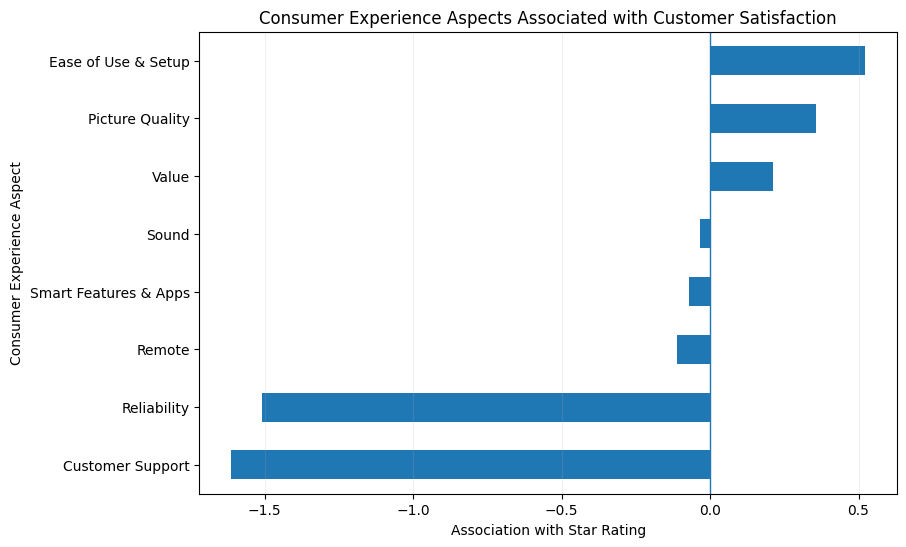

In [38]:
plot_coefficients = (
    comparison["Brand Controlled"]
    .sort_values()
)

plt.figure(
    figsize=(9, 6)
)

plot_coefficients.plot(
    kind="barh"
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel(
    "Association with Star Rating"
)

plt.ylabel(
    "Consumer Experience Aspect"
)

plt.title(
    "Consumer Experience Aspects Associated with Customer Satisfaction"
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.savefig(
    f"{FIGURE_DIR}/04_aspect_rating_associations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
# Calculate the average rating across the five brands
# for each consumer experience aspect

aspect_market_average = (
    rating_matrix.mean(axis=1)
)

# Calculate each brand's rating gap
# relative to the five-brand average

brand_positioning = (
    rating_matrix
    .sub(
        aspect_market_average,
        axis=0
    )
)

display(
    brand_positioning.round(3)
)

brand,Samsung,LG,Sony,TCL,Hisense
aspect,,,,,
Customer Support,-0.175,0.136,0.030,-0.079,0.088
Ease of Use & Setup,-0.001,0.053,0.011,0.070,-0.133
Picture Quality,-0.016,0.119,0.068,-0.038,-0.132
Reliability,-0.063,0.213,0.190,-0.100,-0.239
Remote,0.038,0.177,0.160,0.027,-0.402
Smart Features & Apps,0.018,0.055,0.050,0.112,-0.235
Sound,-0.041,0.162,0.091,-0.080,-0.132
Value,-0.146,0.134,-0.026,0.110,-0.072


In [45]:
import seaborn as sns

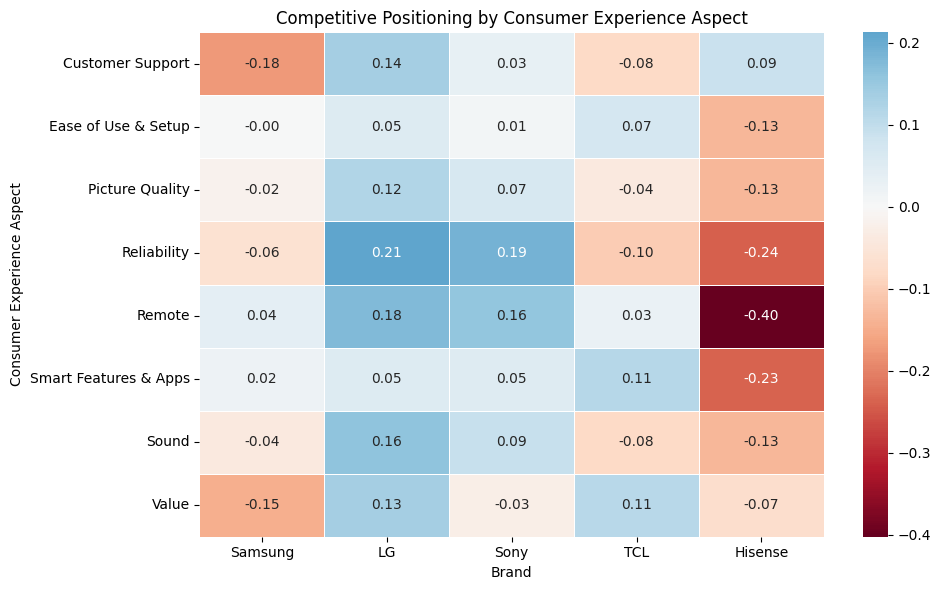

In [46]:
plt.figure(
    figsize=(10, 6)
)

sns.heatmap(
    brand_positioning,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="RdBu",
    linewidths=0.5
)

plt.title(
    "Competitive Positioning by Consumer Experience Aspect"
)

plt.xlabel(
    "Brand"
)

plt.ylabel(
    "Consumer Experience Aspect"
)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/04_brand_aspect_positioning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
aspect_leaders = pd.DataFrame({
    "highest_rated_brand":
        rating_matrix.idxmax(axis=1),

    "highest_rating":
        rating_matrix.max(axis=1),

    "lowest_rated_brand":
        rating_matrix.idxmin(axis=1),

    "lowest_rating":
        rating_matrix.min(axis=1)
})

# Difference between the highest- and lowest-rated brand
aspect_leaders["rating_gap"] = (
    aspect_leaders["highest_rating"]
    - aspect_leaders["lowest_rating"]
)

aspect_leaders = (
    aspect_leaders
    .sort_values(
        "rating_gap",
        ascending=False
    )
)

display(
    aspect_leaders.round(2)
)

,highest_rated_brand,highest_rating,lowest_rated_brand,lowest_rating,rating_gap
aspect,,,,,
Remote,LG,3.98,Hisense,3.40,0.58
Reliability,LG,2.35,Hisense,1.89,0.45
Smart Features & Apps,TCL,3.96,Hisense,3.61,0.35
Customer Support,LG,2.22,Samsung,1.91,0.31
Sound,LG,4.13,Hisense,3.84,0.29
Value,LG,4.16,Samsung,3.88,0.28
Picture Quality,LG,4.25,Hisense,4.00,0.25
Ease of Use & Setup,TCL,4.47,Hisense,4.26,0.20


Picture quality is a highly visible source of satisfaction across the category, while reliability and customer support emerge as lower-frequency but much stronger signals of dissatisfaction. Brand differentiation is also more pronounced in experiences such as remote usability, reliability, and smart features than in picture quality itself.

### Key Findings

The review analysis reveals that consumer satisfaction in the Smart TV market is shaped by different types of product experiences. Picture quality is the most frequently discussed aspect and is positively associated with higher ratings, while ease of use and setup shows the strongest positive association with satisfaction. Value is also positively associated with ratings.

In contrast, reviews mentioning reliability and customer support are strongly associated with lower ratings. These aspects are discussed less frequently than picture quality or value, but when they appear, they often signal serious consumer dissatisfaction. This suggests that the most frequently discussed attributes are not necessarily the experiences most strongly associated with satisfaction or dissatisfaction.

Competitive patterns also differ across brands. LG shows consistently above-average ratings across multiple experience aspects, particularly picture quality, sound, reliability, and value. Sony also performs relatively well in several core product-experience areas. TCL stands out in smart features, ease of use, and value, while Hisense shows comparatively weaker ratings in several areas, especially remote usability, reliability, and smart features. Samsung remains close to the market average across many aspects but shows relatively weaker results for value and customer support.

These findings describe associations in review behavior rather than causal effects. Aspect variables indicate whether consumers discussed an experience, not whether the underlying product attribute was objectively good or bad. The results therefore provide a consumer-perception view of competitive positioning rather than a direct measurement of product quality.